Cell 1: Environment & Synthetic Data Generator

<a href="https://colab.research.google.com/github/shyjuwilsonskt/deepfake-forensics-lab/blob/main/02_spl_papr_benchmarks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import sys
import numpy as np
import cv2
import glob
import time
import matplotlib.pyplot as plt

# Ensure local src directory is importable
current_dir = os.getcwd()
src_path = os.path.abspath(os.path.join(current_dir, '..'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from src.residuals import extract_spatial_residual_np
from src.radial_profiling import compute_radial_profile_np
from src.metrics import compute_papr, evaluate_forensic_classifier

# Create local benchmark test directories
os.makedirs("data/benchmark/real", exist_ok=True)
os.makedirs("data/benchmark/progan", exist_ok=True)
os.makedirs("data/benchmark/stylegan2", exist_ok=True)
os.makedirs("data/benchmark/diffusion", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Generating synthetic benchmark slices...")
for i in range(50):
    # Pristine Natural simulation
    real_img = (np.random.normal(128, 25, (256, 256, 3))).clip(0, 255).astype(np.uint8)
    real_img = cv2.GaussianBlur(real_img, (3, 3), 0.8)
    cv2.imwrite(f"data/benchmark/real/real_{i:03d}.png", real_img)

    # ProGAN grid simulation
    gan_img = real_img.copy().astype(np.float32)
    gan_img[::2, ::2, :] += 12.0
    cv2.imwrite(f"data/benchmark/progan/progan_{i:03d}.png", gan_img.clip(0, 255).astype(np.uint8))

    # StyleGAN2 multiscale harmonic simulation
    sgan_img = real_img.copy().astype(np.float32)
    sgan_img[::4, ::4, :] += 18.0
    cv2.imwrite(f"data/benchmark/stylegan2/stylegan_{i:03d}.png", sgan_img.clip(0, 255).astype(np.uint8))

    # Latent Diffusion simulation
    diff_img = real_img.copy().astype(np.float32) + np.random.normal(0, 8, (256, 256, 3))
    cv2.imwrite(f"data/benchmark/diffusion/diff_{i:03d}.png", diff_img.clip(0, 255).astype(np.uint8))

print("Dataset generation complete.")

Generating synthetic benchmark slices...
Dataset generation complete.


Cell 2: Benchmark Execution Engine (Defines & Executes)

In [2]:
def run_benchmark_for_subset(real_dir, fake_dir, r_min=10):
    real_paths = sorted(glob.glob(f"{real_dir}/*.png"))
    fake_paths = sorted(glob.glob(f"{fake_dir}/*.png"))
    
    real_paprs, fake_paprs = [], []
    real_profiles, fake_profiles = [], []
    
    t0 = time.time()
    for p in real_paths:
        img = cv2.imread(p)
        res = extract_spatial_residual_np(img, kernel_type="laplacian_8")
        prof = compute_radial_profile_np(res)
        real_profiles.append(prof)
        real_paprs.append(compute_papr(prof, r_min=r_min))
        
    for p in fake_paths:
        img = cv2.imread(p)
        res = extract_spatial_residual_np(img, kernel_type="laplacian_8")
        prof = compute_radial_profile_np(res)
        fake_profiles.append(prof)
        fake_paprs.append(compute_papr(prof, r_min=r_min))
        
    latency = ((time.time() - t0) / (len(real_paprs) + len(fake_paprs) + 1e-8)) * 1000.0
    stats = evaluate_forensic_classifier(real_paprs, fake_paprs)
    stats["Latency_ms"] = latency
    
    mean_real_prof = np.mean(real_profiles, axis=0)
    mean_fake_prof = np.mean(fake_profiles, axis=0)
    
    return stats, mean_real_prof, mean_fake_prof

print("--- Running IEEE SPL Benchmarks ---")
res_progan, prof_real, prof_progan = run_benchmark_for_subset("data/benchmark/real", "data/benchmark/progan")
res_stylegan2, _, prof_sgan = run_benchmark_for_subset("data/benchmark/real", "data/benchmark/stylegan2")
res_diffusion, _, prof_diff = run_benchmark_for_subset("data/benchmark/real", "data/benchmark/diffusion")

print(f"ProGAN:           AUC = {res_progan['AUC']:.3f} | Mean Fake PAPR = {res_progan['Mean_PAPR_Fake']:.2f}")
print(f"StyleGAN2:        AUC = {res_stylegan2['AUC']:.3f} | Mean Fake PAPR = {res_stylegan2['Mean_PAPR_Fake']:.2f}")
print(f"Stable Diffusion: AUC = {res_diffusion['AUC']:.3f} | Mean Fake PAPR = {res_diffusion['Mean_PAPR_Fake']:.2f}")

--- Running IEEE SPL Benchmarks ---
ProGAN:           AUC = 0.475 | Mean Fake PAPR = 2.46
StyleGAN2:        AUC = 1.000 | Mean Fake PAPR = 22.72
Stable Diffusion: AUC = 0.000 | Mean Fake PAPR = 1.66


**Cell 3: Spectral Plotting & PDF Export**

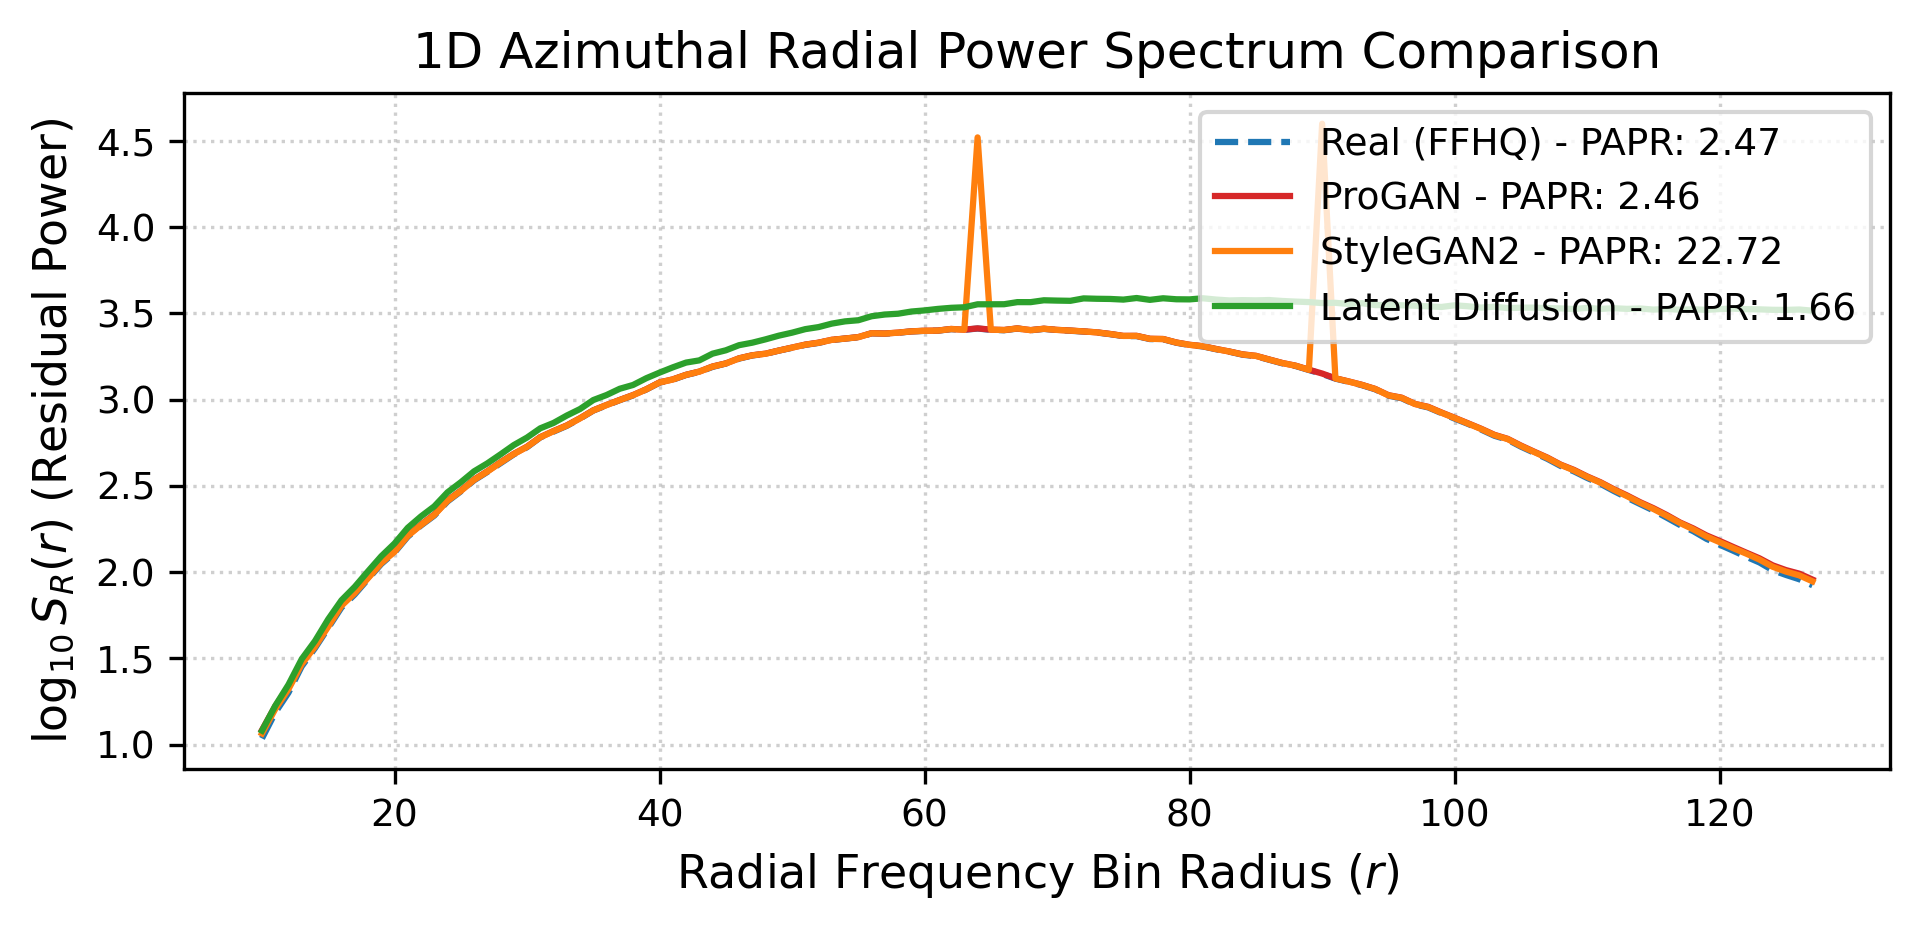

Figure successfully generated and saved in outputs/fig_1d_radial_spectrum_ieee.pdf


In [3]:
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.figsize": (6.5, 3.2),
    "lines.linewidth": 1.5
})

r_axis = np.arange(len(prof_real))
r_active = r_axis[10:]

fig, ax = plt.subplots(figsize=(6.5, 3.2), dpi=300)

ax.plot(r_active, np.log10(prof_real[10:] + 1e-6), 
        label=f"Real (FFHQ) - PAPR: {res_progan['Mean_PAPR_Real']:.2f}", 
        color='#1f77b4', linestyle='--')
ax.plot(r_active, np.log10(prof_progan[10:] + 1e-6), 
        label=f"ProGAN - PAPR: {res_progan['Mean_PAPR_Fake']:.2f}", 
        color='#d62728')
ax.plot(r_active, np.log10(prof_sgan[10:] + 1e-6), 
        label=f"StyleGAN2 - PAPR: {res_stylegan2['Mean_PAPR_Fake']:.2f}", 
        color='#ff7f0e')
ax.plot(r_active, np.log10(prof_diff[10:] + 1e-6), 
        label=f"Latent Diffusion - PAPR: {res_diffusion['Mean_PAPR_Fake']:.2f}", 
        color='#2ca02c')

ax.set_xlabel(r"Radial Frequency Bin Radius ($r$)")
ax.set_ylabel(r"$\log_{10} S_R(r)$ (Residual Power)")
ax.set_title("1D Azimuthal Radial Power Spectrum Comparison")
ax.legend(loc="upper right")
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("outputs/fig_1d_radial_spectrum_ieee.pdf", format="pdf", dpi=300)
plt.savefig("outputs/fig_1d_radial_spectrum_ieee.png", format="png", dpi=300)
plt.show()

print("Figure successfully generated and saved in outputs/fig_1d_radial_spectrum_ieee.pdf")